# Weather Prediction project by :

Student: **Mahmoud Elaidi** ID: **224101559**

Student: **Keroles Amgad** ID: **224101546**

Student: **Mahmoud Mohamed** ID: **224101560**

Student: **Youssef Mahmoud** ID: **224101567**

---

**Dataset:** Seattle Weather (1461 daily records, 2012–2015)  
**Source:** https://www.kaggle.com/datasets/ananthr1/weather-prediction  
**Goal:** Predict weather type (sun, rain, fog, drizzle, snow) using 4 algorithms: Random Forest, KNN, SVM, XGBoost.

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Dataset from URL (no local file needed)
url = 'https://vega.github.io/vega-datasets/data/seattle-weather.csv'
df = pd.read_csv(url)
print('Shape:', df.shape)
df.head()

Shape: (1461, 6)


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [3]:
# Preprocessing
df = df.drop(columns=['date'])
le = LabelEncoder()
df['weather'] = le.fit_transform(df['weather'])
class_names = list(le.classes_)

X = df.drop(columns=['weather'])
y = df['weather']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Classes:', class_names)

Train: (1168, 4) | Test: (293, 4)
Classes: ['drizzle', 'fog', 'rain', 'snow', 'sun']


In [4]:
# Evaluation Function
results = {}

def evaluate(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1}

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()


=== Random Forest ===
Accuracy: 0.6587 | Precision: 0.6376 | Recall: 0.6587 | F1: 0.6428
              precision    recall  f1-score   support

     drizzle       0.17      0.09      0.12        11
         fog       0.57      0.63      0.60        82
        rain       0.48      0.31      0.38        52
        snow       0.50      0.60      0.55         5
         sun       0.78      0.85      0.81       143

    accuracy                           0.66       293
   macro avg       0.50      0.50      0.49       293
weighted avg       0.64      0.66      0.64       293



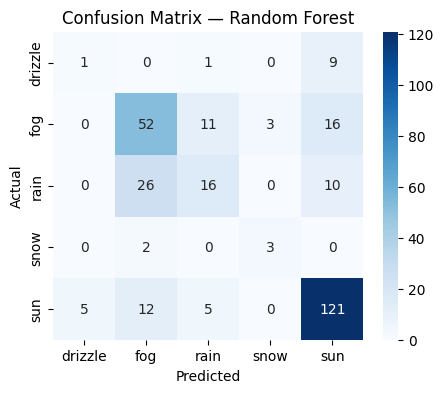

In [5]:
# Model 1: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
evaluate('Random Forest', y_test, rf.predict(X_test))


=== KNN ===
Accuracy: 0.6382 | Precision: 0.6083 | Recall: 0.6382 | F1: 0.6161
              precision    recall  f1-score   support

     drizzle       0.33      0.09      0.14        11
         fog       0.56      0.65      0.60        82
        rain       0.46      0.31      0.37        52
        snow       0.00      0.00      0.00         5
         sun       0.73      0.82      0.77       143

    accuracy                           0.64       293
   macro avg       0.42      0.37      0.38       293
weighted avg       0.61      0.64      0.62       293



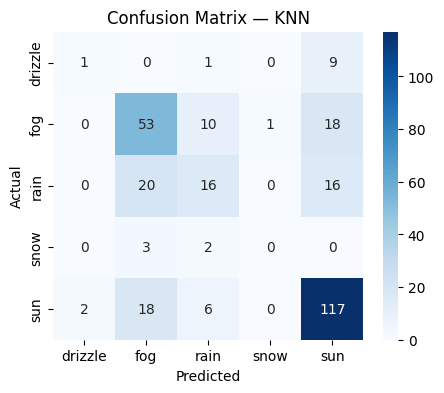

In [6]:
# Model 2: KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
evaluate('KNN', y_test, knn.predict(X_test_scaled))


=== SVM ===
Accuracy: 0.6553 | Precision: 0.6134 | Recall: 0.6553 | F1: 0.6101
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00        11
         fog       0.63      0.50      0.56        82
        rain       0.48      0.25      0.33        52
        snow       1.00      0.20      0.33         5
         sun       0.69      0.96      0.80       143

    accuracy                           0.66       293
   macro avg       0.56      0.38      0.40       293
weighted avg       0.61      0.66      0.61       293



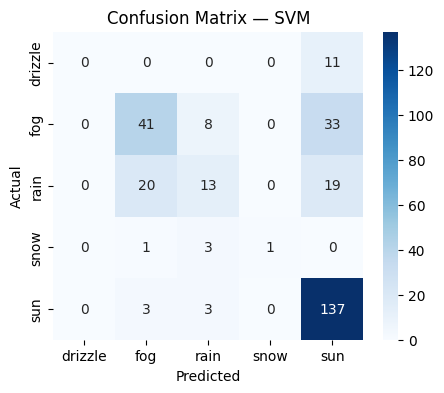

In [7]:
# Model 3: SVM
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)
evaluate('SVM', y_test, svm.predict(X_test_scaled))


=== XGBoost ===
Accuracy: 0.6860 | Precision: 0.6595 | Recall: 0.6860 | F1: 0.6636
              precision    recall  f1-score   support

     drizzle       0.25      0.09      0.13        11
         fog       0.60      0.61      0.60        82
        rain       0.55      0.33      0.41        52
        snow       0.50      0.60      0.55         5
         sun       0.77      0.91      0.84       143

    accuracy                           0.69       293
   macro avg       0.53      0.51      0.51       293
weighted avg       0.66      0.69      0.66       293



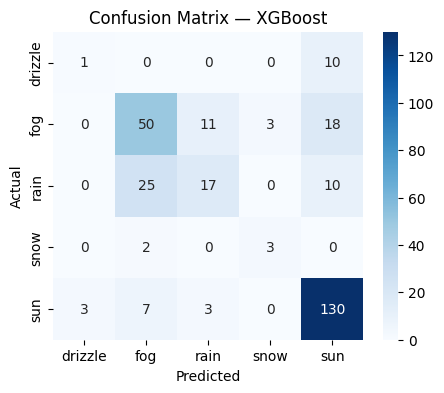

In [8]:
# Model 4: XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                     use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
evaluate('XGBoost', y_test, xgb.predict(X_test))

               Accuracy  Precision  Recall  F1-score
Random Forest    0.6587     0.6376  0.6587    0.6428
KNN              0.6382     0.6083  0.6382    0.6161
SVM              0.6553     0.6134  0.6553    0.6101
XGBoost          0.6860     0.6595  0.6860    0.6636


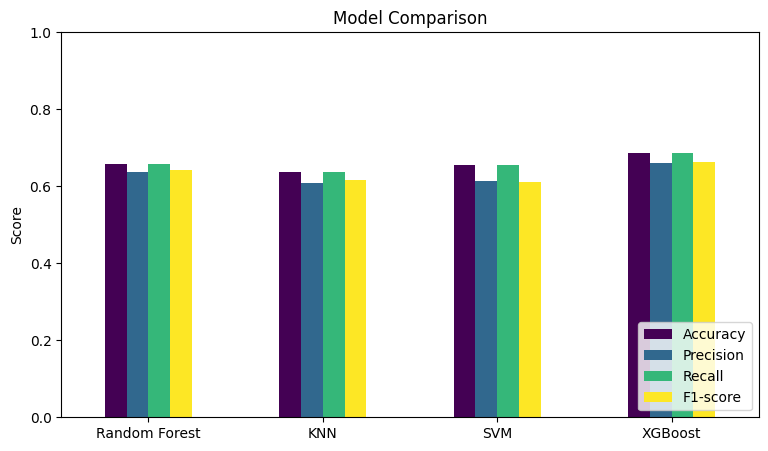


Best Model: XGBoost


In [9]:
# Final Comparison
results_df = pd.DataFrame(results).T.round(4)
print(results_df)

results_df.plot(kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Model Comparison')
plt.ylabel('Score'); plt.ylim(0, 1); plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

print(f'\nBest Model: {results_df["F1-score"].idxmax()}')